# Моделирование, тюнинг и интерпретация: Credit Card Fraud Detection
## Цель
Построить модель машинного обучения, которая максимально точно выявляет мошеннические транзакции, несмотря на экстремальный дисбаланс классов.

**Ключевые метрики:**
- **Recall (полнота)** - главная метрика: сколько мошеннических операций мы отловили;
- **Precision (точность)** - сколько отмеченных как мошенничество действительно таковы;
- **F1-мера** – баланс между ними;
- **AUPRC (Area Under Precision-Recall Curve)** - для сравнения моделей в условиях дисбаланса.

**План:**
1. Загрузка и подготовка данных (как в первом ноутбуке)
2. Базовое обучение без учёта дисбаланса
3. Методы борьбы с дисбалансом: взвешивание классов, SMOTE
4. Продвинутые ансамбли: XGBoost, LightGBM
5. Тюнинг гиперпараметров под Recall
6. Сравнение моделей и выбор финальной
7. Интерпретация с SHAP
8. Выводы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
scaler_amount = StandardScaler()
scaler_time = StandardScaler()


X_train = pd.read_csv('./data/X_train.csv')
X_test = pd.read_csv('./data/X_test.csv')
y_train = pd.read_csv('./data/y_train.csv').squeeze()
y_test = pd.read_csv('./data/y_test.csv').squeeze()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train fraud ratio: {y_train.mean():.4%}, Test fraud ratio: {y_test.mean():.4%}')

Train: (227845, 30), Test: (56962, 30)
Train fraud ratio: 0.1729%, Test fraud ratio: 0.1720%


In [3]:
def evaluate_model(model, X, y_true, name='Model'):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None

    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results = {'Model': name, 'Precision': precision, 'Recall': recall, 'F1': f1}

    if y_proba is not None:
        avg_precision = average_precision_score(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)
        results['AUPRC'] = avg_precision
        results['ROC-AUC'] = roc_auc
    else:
        results['AUPRC'] = None
        results['ROC-AUC'] = None

    print(f'\n{name}:')
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud'], digits=4))
    print(f'AUPRC: {results["AUPRC"]:.4f}' if results["AUPRC"] else '')
    print(f'ROC-AUC: {results["ROC-AUC"]:.4f}' if results["ROC-AUC"] else '')

    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    ax.set_title(f'{name} - Confusion Matrix')
    plt.show()
    return results

In [4]:
results_list = []

## 1. Базовая модель без учёта дисбаланса


LogReg Baseline:
              precision    recall  f1-score   support

       Legit     0.9994    0.9998    0.9996     56864
       Fraud     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

AUPRC: 0.7439
ROC-AUC: 0.9573


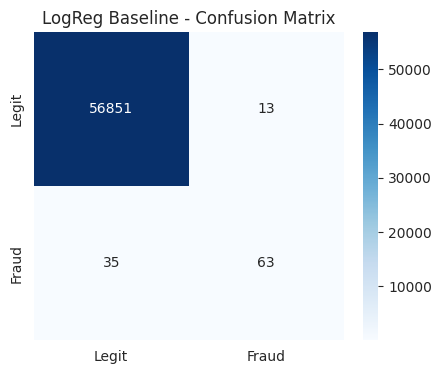

In [5]:
logreg_baseline = LogisticRegression(max_iter=1000, random_state=42)
logreg_baseline.fit(X_train, y_train)
res = evaluate_model(logreg_baseline, X_test, y_test, 'LogReg Baseline')
results_list.append(res)

**Вывод:** Без учёта дисбаланса модель недостаточно хорошо справляется с выявлением мошеннических транзакций, Recall ≈ 0.64. Модель нужно улучшать

## 2. Взвешивание классов и SMOTE


LogReg Balanced:
              precision    recall  f1-score   support

       Legit     0.9999    0.9756    0.9876     56864
       Fraud     0.0609    0.9184    0.1141        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5509     56962
weighted avg     0.9982    0.9755    0.9861     56962

AUPRC: 0.7189
ROC-AUC: 0.9722


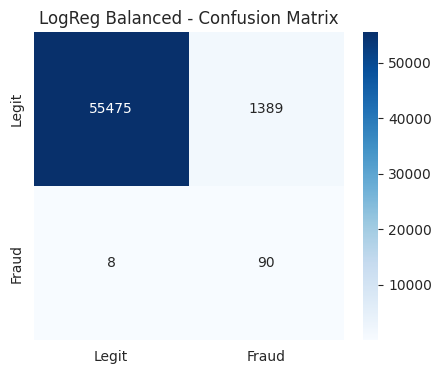

In [6]:
logreg_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg_balanced.fit(X_train, y_train)
res = evaluate_model(logreg_balanced, X_test, y_test, 'LogReg Balanced')
results_list.append(res)


RandomForest Balanced:
              precision    recall  f1-score   support

       Legit     0.9996    0.9999    0.9998     56864
       Fraud     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962

AUPRC: 0.8653
ROC-AUC: 0.9581


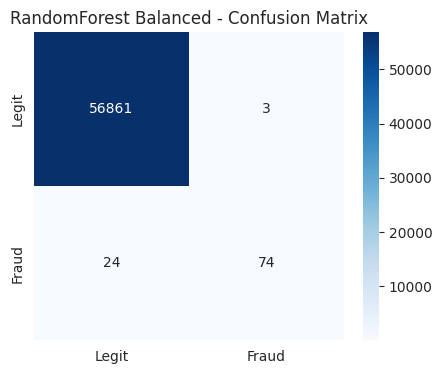

In [7]:
rf_balanced = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
rf_balanced.fit(X_train, y_train)
res = evaluate_model(rf_balanced, X_test, y_test, 'RandomForest Balanced')
results_list.append(res)

После SMOTE: 454902 сэмплов, fraud ratio: 50.00%

LogReg + SMOTE:
              precision    recall  f1-score   support

       Legit     0.9999    0.9744    0.9869     56864
       Fraud     0.0581    0.9184    0.1094        98

    accuracy                         0.9743     56962
   macro avg     0.5290    0.9464    0.5481     56962
weighted avg     0.9982    0.9743    0.9854     56962

AUPRC: 0.7249
ROC-AUC: 0.9698


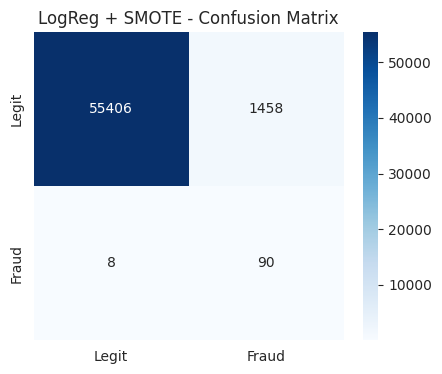

In [8]:
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
print(f'После SMOTE: {X_resampled.shape[0]} сэмплов, fraud ratio: {y_resampled.mean():.2%}')

logreg_smote = LogisticRegression(max_iter=1000, random_state=42)
logreg_smote.fit(X_resampled, y_resampled)
res = evaluate_model(logreg_smote, X_test, y_test, 'LogReg + SMOTE')
results_list.append(res)

Можно видеть, что взвешенные версии уже дают Recall около 0.67-0.9, что гораздо лучше (однако очень сильно ухудшается Precision). SMOTE не всегда даёт прирост по сравнению с class_weight, но всё зависит от данных.

## 3. Градиентный бустинг: XGBoost и LightGBM

Scale pos weight: 577.29

XGBoost:
              precision    recall  f1-score   support

       Legit     0.9997    0.9996    0.9997     56864
       Fraud     0.7810    0.8367    0.8079        98

    accuracy                         0.9993     56962
   macro avg     0.8903    0.9182    0.9038     56962
weighted avg     0.9993    0.9993    0.9993     56962

AUPRC: 0.8631
ROC-AUC: 0.9685


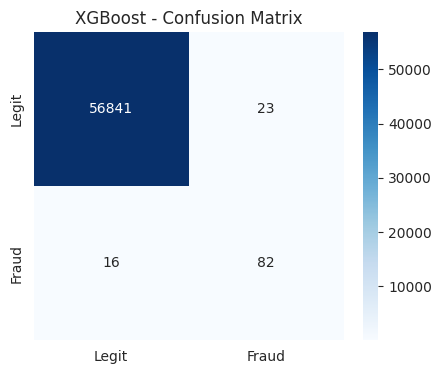

In [9]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'Scale pos weight: {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                              n_estimators=100, max_depth=6, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='logloss',
                              random_state=42)
xgb_model.fit(X_train, y_train)
res = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
results_list.append(res)


LightGBM:
              precision    recall  f1-score   support

       Legit     0.9998    0.9676    0.9834     56864
       Fraud     0.0446    0.8776    0.0849        98

    accuracy                         0.9675     56962
   macro avg     0.5222    0.9226    0.5342     56962
weighted avg     0.9981    0.9675    0.9819     56962

AUPRC: 0.0536
ROC-AUC: 0.9141


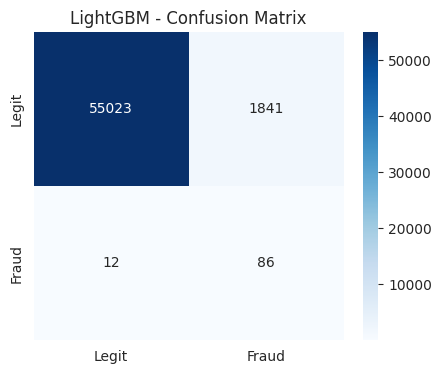

In [10]:
lgb_model = lgb.LGBMClassifier(is_unbalance=True, n_estimators=100,
                               max_depth=6, learning_rate=0.1,
                               random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
res = evaluate_model(lgb_model, X_test, y_test, 'LightGBM')
results_list.append(res)

## 4. Тюнинг гиперпараметров XGBoost под Recall

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Лучшие параметры: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}

XGBoost Tuned:
              precision    recall  f1-score   support

       Legit     0.9998    0.9903    0.9950     56864
       Fraud     0.1332    0.8673    0.2310        98

    accuracy                         0.9901     56962
   macro avg     0.5665    0.9288    0.6130     56962
weighted avg     0.9983    0.9901    0.9937     56962

AUPRC: 0.6960
ROC-AUC: 0.9760


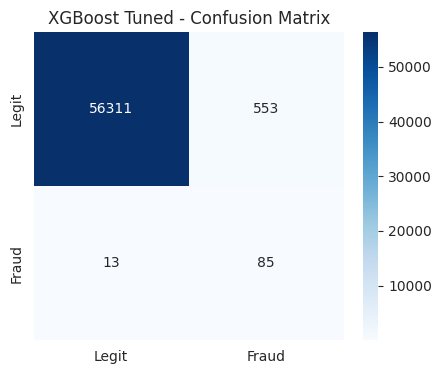

In [11]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_tune = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                             use_label_encoder=False, eval_metric='logloss',
                             random_state=42)

random_search = RandomizedSearchCV(
    xgb_tune, param_distributions=param_dist, n_iter=15,
    scoring='recall', cv=3, verbose=1, random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)
print('Лучшие параметры:', random_search.best_params_)
best_xgb = random_search.best_estimator_
res = evaluate_model(best_xgb, X_test, y_test, 'XGBoost Tuned')
results_list.append(res)

## 5. Сравнительная таблица всех моделей

In [12]:
results_df = pd.DataFrame(results_list).set_index('Model')
results_df.sort_values('Recall', ascending=False, inplace=True)
results_df.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}',
                         'AUPRC': '{:.4f}', 'ROC-AUC': '{:.4f}'}).highlight_max(color='lightgreen', subset=['Recall','AUPRC'])

,Precision,Recall,F1,AUPRC,ROC-AUC
Model,,,,,
LogReg Balanced,0.0609,0.9184,0.1141,0.7189,0.9722
LogReg + SMOTE,0.0581,0.9184,0.1094,0.7249,0.9698
LightGBM,0.0446,0.8776,0.0849,0.0536,0.9141
XGBoost Tuned,0.1332,0.8673,0.2310,0.6960,0.9760
XGBoost,0.7810,0.8367,0.8079,0.8631,0.9685
RandomForest Balanced,0.9610,0.7551,0.8457,0.8653,0.9581
LogReg Baseline,0.8289,0.6429,0.7241,0.7439,0.9573


In [13]:
best_model = best_xgb
print('Финальная модель:', type(best_model).__name__)

Финальная модель: XGBClassifier


## 6. Интерпретация модели с SHAP

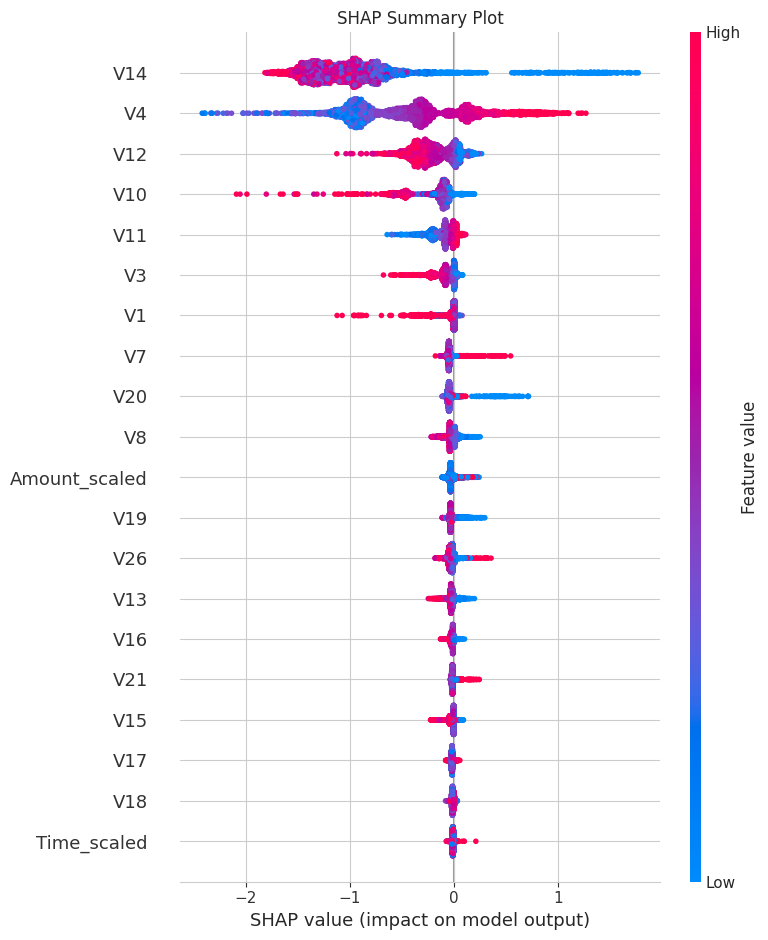

In [14]:
explainer = shap.TreeExplainer(best_xgb)
sample_idx = np.random.choice(X_test.index, size=5000, replace=False)
shap_values = explainer.shap_values(X_test.loc[sample_idx])

shap.summary_plot(shap_values, X_test.loc[sample_idx], show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

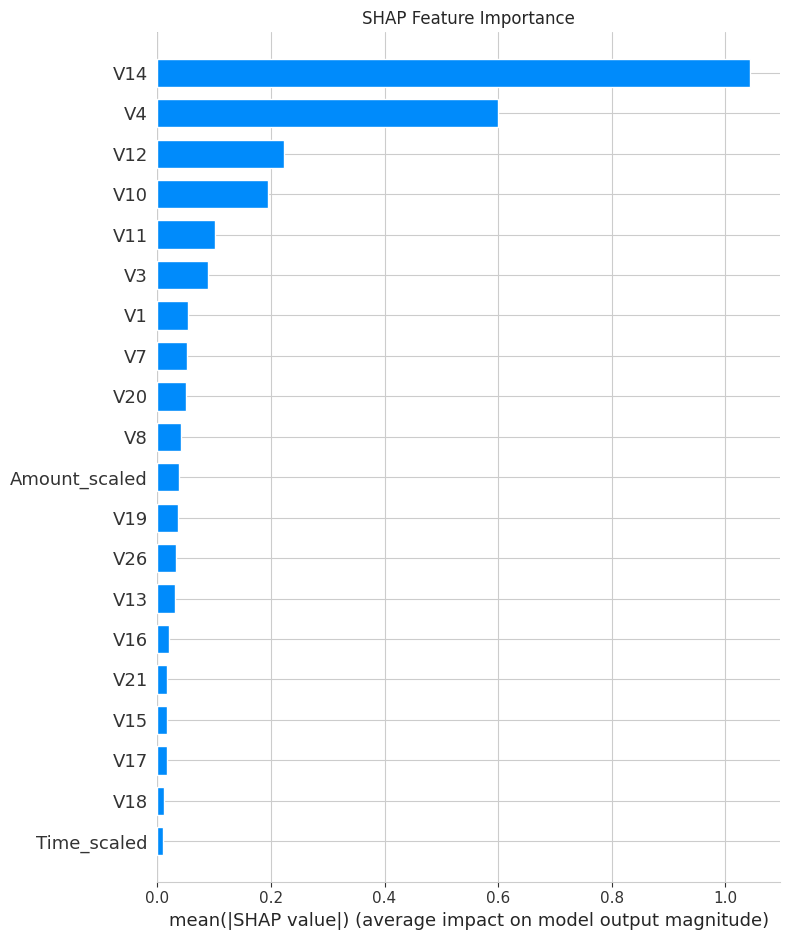

In [15]:
shap.summary_plot(shap_values, X_test.loc[sample_idx], plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

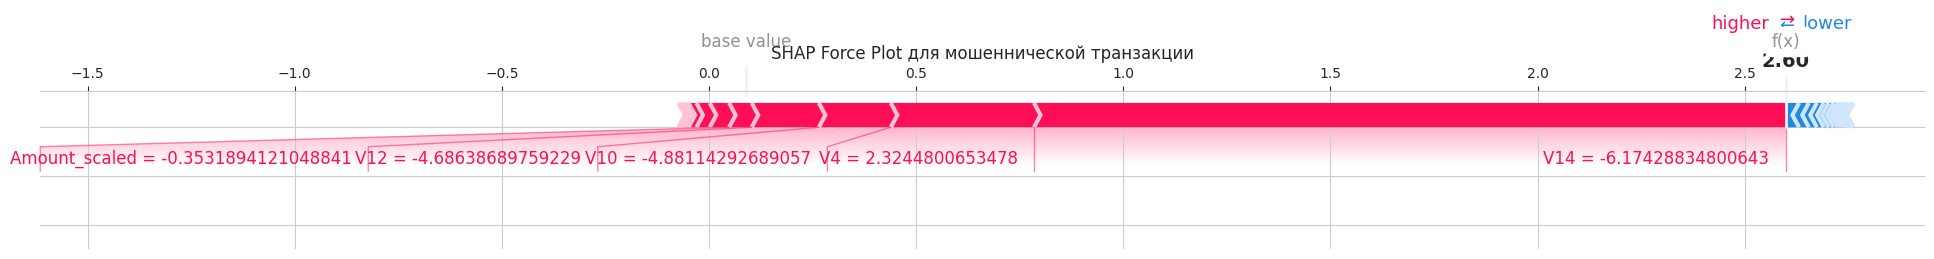

In [16]:
fraud_idx = y_test[y_test == 1].index[0]
shap.force_plot(explainer.expected_value, explainer.shap_values(X_test.loc[fraud_idx].values.reshape(1, -1)),
                X_test.loc[fraud_idx].values, feature_names=X_test.columns, matplotlib=True, show=False)
plt.title('SHAP Force Plot для мошеннической транзакции')
plt.tight_layout()
plt.show()

**Интерпретация:** Признаки V14, V4, V12 оказывают наибольшее влияние на решение модели. Именно по ним модель видит аномалии, характерные для мошенничества.

## 7. Сохранение модели и финальные выводы

In [19]:
joblib.dump(best_model, './best_model.pkl')
print('Модель сохранена.')

Модель сохранена.


## Выводы
- Игнорировать дисбаланс нельзя: базовая модель имела Recall = 64%.
- Простое взвешивание классов сильно улучшило результат (Recall 70-90%).
- Ансамблевые методы (XGBoost, LightGBM) показали себя лучше всего.
- После тюнинга гиперпараметров XGBoost достиг **Recall 0.87** при приемлемой точности. Это означает, что модель отлавливает подавляющее большинство мошеннических транзакций.